# Laboratorio 4: análisis de datos geoespaciales — lagos Atitlán y Amatitlán

Este notebook implementa el flujo completo de adquisición y análisis para los lagos Atitlán y Amatitlán usando Sentinel-2 L2A mediante openEO. Se utilizan únicamente las fechas oficiales de la guía.

**Ejercicios cubiertos:** 1) conexión a la API, 2) obtención de datos, 3) cálculo de NDVI, NDWI y NDCI para cianobacterias, 4) análisis temporal (promedio por lago y fecha), 5) análisis espacial (mapas interactivos y comparativos), 6) correlación de NDVI/NDWI con la cianobacteria, 7) comparación entre lagos, y 8) análisis exploratorio adicional (extensión espacial, zonas persistentes, distribución entre fechas y patrón estacional).

El NDCI es el índice cuantitativo de cianobacterias utilizado en el script de Sentinel Hub: `(B05 - B04) / (B05 + B04)`. Se reporta como indicador espectral de clorofila-a/cianobacterias y no como una medición de laboratorio.

## 0. Dependencias y configuración

Si alguna dependencia no está instalada, ejecute `pip install openeo rasterio geopandas shapely numpy pandas matplotlib` en el entorno del notebook. La autenticación OIDC se realiza en el navegador y requiere una cuenta de Copernicus Data Space.

In [1]:
from datetime import date, timedelta
from pathlib import Path
import warnings

import folium
import geopandas as gpd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio
from branca.colormap import LinearColormap
from rasterio.features import geometry_mask
from rasterio.transform import array_bounds
from rasterio.warp import Resampling as WarpResampling
from rasterio.warp import calculate_default_transform, reproject
from shapely.geometry import box

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "GIS" / "lab4_avance"
DATA_DIR.mkdir(parents=True, exist_ok=True)
API_URL = "https://openeo.dataspace.copernicus.eu"
COLLECTION = "SENTINEL2_L2A"
# Las bandas se solicitan en el mismo orden en que se interpretan localmente.
BANDS = ["B02", "B03", "B04", "B05", "B08", "SCL"]
NDCI_HIGH_THRESHOLD = 0.20
print(f"Datos de salida: {DATA_DIR.resolve()}")

/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Datos de salida: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance


## 1. Áreas y fechas oficiales

Las extensiones corresponden a la guía del laboratorio. Para cada fecha se solicita una ventana de un día, porque openEO espera un intervalo temporal y la fecha final es exclusiva en muchos backends.

In [2]:
LAKES = {
    "Atitlan": {
        "west": -91.326256, "east": -91.07151,
        "south": 14.5948, "north": 14.750979,
    },
    "Amatitlan": {
        "west": -90.638065, "east": -90.512924,
        "south": 14.412347, "north": 14.493799,
    },
}

OFFICIAL_DATES = {
    "Atitlan": [
        "2025-01-18", "2025-04-13", "2025-05-13",
        "2025-07-17", "2025-11-21", "2025-12-29",
        "2026-02-12", "2026-03-24", "2026-04-13",
        "2026-04-28", "2026-07-22",
    ],
    "Amatitlan": [
        "2025-01-28", "2025-04-15", "2025-04-28",
        "2025-11-24", "2026-01-08", "2026-02-02",
        "2026-02-07", "2026-03-29", "2026-04-13",
        "2026-04-28", "2026-06-19",
    ],
}

assert set(LAKES) == set(OFFICIAL_DATES)
assert all(len(v) == 11 for v in OFFICIAL_DATES.values())
print("Configuración validada: 2 lagos y 11 fechas oficiales por lago.")

Configuración validada: 2 lagos y 11 fechas oficiales por lago.


## 2. Geometrías de trabajo

Si existe un GeoJSON proporcionado por el curso, se utiliza para calcular estadísticas solamente sobre el cuerpo de agua. Como respaldo reproducible, el notebook construye un polígono con el bounding box oficial. El respaldo permite ejecutar el flujo, pero para la entrega final se debe preferir el GeoJSON, porque el bounding box incluye tierra.

In [3]:
def find_lake_geometry(lake_name, extent):
    candidates = [
        p for p in list(BASE_DIR.rglob("*.geojson")) + list(BASE_DIR.rglob("*.json"))
        if not any(part.startswith(".") or part in ("data",) for part in p.relative_to(BASE_DIR).parts[:-1])
        and lake_name.lower() in p.name.lower()
    ]
    for path in candidates:
        try:
            frame = gpd.read_file(path)
            if frame.empty or frame.geometry.isna().any() or frame.geometry.is_empty.any():
                continue
            frame = frame.to_crs("EPSG:4326")
            return frame[["geometry"]], f"GeoJSON: {path.name}"
        except Exception:
            continue
    fallback = gpd.GeoDataFrame(
        {"geometry": [box(extent["west"], extent["south"], extent["east"], extent["north"])]},
        crs="EPSG:4326",
    )
    return fallback, "Bounding box oficial (respaldo)"

GEOMETRIES = {}
for lake_name, extent in LAKES.items():
    GEOMETRIES[lake_name], source = find_lake_geometry(lake_name, extent)
    print(f"{lake_name}: {source}")

Atitlan: Bounding box oficial (respaldo)


Amatitlan: Bounding box oficial (respaldo)


## Ejercicio 1. Conexión con openEO

La siguiente celda abre la conexión y ejecuta OIDC. No se guardan credenciales en el notebook.

In [4]:
connection = openeo.connect(API_URL)
connection = connection.authenticate_oidc()
print(f"Conexión autenticada: {API_URL}")
print("Backend: ", connection.describe_account())

Authenticated using refresh token.
Conexión autenticada: https://openeo.dataspace.copernicus.eu


Backend:  {'info': {'oidc_userinfo': {'email': 'pad23663@uvg.edu.gt', 'email_verified': True, 'family_name': 'Padilla', 'given_name': 'Luis', 'name': 'Luis Padilla', 'preferred_username': 'pad23663@uvg.edu.gt', 'sub': '6d5c54ba-eb01-45fb-b63a-42c48bbcf64c'}}, 'name': 'Luis Padilla', 'user_id': '6d5c54ba-eb01-45fb-b63a-42c48bbcf64c'}


## Ejercicio 2. Descarga de escenas Sentinel-2 L2A

Se descarga una escena por lago y fecha. Se incluyen B02-B05 y B08 para los índices, y SCL para excluir píxeles de nubes, sombras y datos inválidos. Los GeoTIFF se conservan localmente para que el análisis sea reproducible sin volver a consultar la API.

In [5]:
def scene_path(lake_name, date_text):
    return DATA_DIR / f"{lake_name}_{date_text}.tif"

def download_scene(connection, lake_name, date_text):
    target = scene_path(lake_name, date_text)
    if target.exists() and target.stat().st_size > 0:
        return target
    start = date.fromisoformat(date_text)
    end = start + timedelta(days=1)
    cube = connection.load_collection(
        COLLECTION,
        spatial_extent=LAKES[lake_name],
        temporal_extent=[start.isoformat(), end.isoformat()],
        bands=BANDS,
    )
    job = connection.create_job(
        cube.save_result(format="GTIFF"),
        title=f"Lab4_{lake_name}_{date_text}",
    )
    job.start_and_wait()
    job.download_results(str(target))
    if not target.exists():
        raise FileNotFoundError(f"openEO no creó {target}")
    return target

scene_files = []
for lake_name in LAKES:
    for date_text in OFFICIAL_DATES[lake_name]:
        path = download_scene(connection, lake_name, date_text)
        scene_files.append((lake_name, date_text, path))
        print(f"Disponible: {path.name}")
print(f"Escenas disponibles: {len(scene_files)}")

Disponible: Atitlan_2025-01-18.tif
Disponible: Atitlan_2025-04-13.tif
Disponible: Atitlan_2025-05-13.tif
Disponible: Atitlan_2025-07-17.tif
Disponible: Atitlan_2025-11-21.tif
Disponible: Atitlan_2025-12-29.tif
Disponible: Atitlan_2026-02-12.tif
Disponible: Atitlan_2026-03-24.tif
Disponible: Atitlan_2026-04-13.tif
Disponible: Atitlan_2026-04-28.tif
Disponible: Atitlan_2026-07-22.tif
Disponible: Amatitlan_2025-01-28.tif
Disponible: Amatitlan_2025-04-15.tif
Disponible: Amatitlan_2025-04-28.tif
Disponible: Amatitlan_2025-11-24.tif
Disponible: Amatitlan_2026-01-08.tif
Disponible: Amatitlan_2026-02-02.tif
Disponible: Amatitlan_2026-02-07.tif
Disponible: Amatitlan_2026-03-29.tif
Disponible: Amatitlan_2026-04-13.tif
Disponible: Amatitlan_2026-04-28.tif
Disponible: Amatitlan_2026-06-19.tif
Escenas disponibles: 22


## Ejercicio 3. Preprocesamiento e índices espectrales

Las expresiones se calculan píxel a píxel: NDVI para vegetación, NDWI para agua y NDCI para clorofila-a/cianobacterias. Se utiliza SCL para descartar nodata, sombras y nubes; además, la geometría del lago limita el cálculo espacial.

In [6]:
def safe_normalized_difference(a, b):
    denominator = a + b
    return np.divide(a - b, denominator, out=np.full_like(a, np.nan, dtype=np.float32), where=denominator != 0)

def read_scene(path, lake_name):
    with rasterio.open(path) as src:
        raw = src.read()
        transform = src.transform
        crs = src.crs
        descriptions = list(src.descriptions)
    names = [d.upper() if d else BANDS[i] for i, d in enumerate(descriptions)]
    band_map = {name: raw[i] for i, name in enumerate(names)}
    missing = set(BANDS) - set(band_map)
    if missing:
        raise ValueError(f"Faltan bandas {missing} en {path.name}; descripciones={descriptions}")
    scale = {name: band_map[name].astype(np.float32) / 10000.0 for name in BANDS if name != "SCL"}
    ndvi = safe_normalized_difference(scale["B08"], scale["B04"])
    ndwi = safe_normalized_difference(scale["B03"], scale["B08"])
    ndci = safe_normalized_difference(scale["B05"], scale["B04"])
    scl = band_map["SCL"]
    # SCL: 0 nodata, 1 saturado, 3 sombra, 8-10 nubes, 11 nieve/hielo.
    clear = ~np.isin(scl, [0, 1, 3, 8, 9, 10, 11])
    geometry = GEOMETRIES[lake_name].to_crs(crs)
    inside = geometry_mask(geometry.geometry, out_shape=ndci.shape, transform=transform, invert=True)
    valid = clear & inside & np.isfinite(ndci) & np.isfinite(ndvi) & np.isfinite(ndwi)
    return {
        "ndvi": ndvi, "ndwi": ndwi, "ndci": ndci, "valid": valid, "inside": inside, "clear": clear,
        "transform": transform, "crs": crs,
    }

def summarize_scene(indices, lake_name, date_text):
    mask = indices["valid"]
    ndci = indices["ndci"][mask]
    ndvi = indices["ndvi"][mask]
    ndwi = indices["ndwi"][mask]
    if ndci.size == 0:
        raise ValueError(f"No hay píxeles válidos para {lake_name} {date_text}")
    return {
        "lake": lake_name, "date": pd.Timestamp(date_text),
        "ndci_mean": float(np.mean(ndci)),
        "ndci_median": float(np.median(ndci)),
        "ndci_p90": float(np.percentile(ndci, 90)),
        "ndci_high_fraction": float(np.mean(ndci >= NDCI_HIGH_THRESHOLD)),
        "ndvi_mean": float(np.mean(ndvi)),
        "ndwi_mean": float(np.mean(ndwi)),
        "valid_pixels": int(ndci.size),
        "clear_fraction": float(np.mean(indices["clear"][indices["inside"]])) ,
    }

In [7]:
# Verificación local de fórmulas y manejo de división por cero.
a = np.array([[0.2, 0.0]], dtype=np.float32)
b = np.array([[0.4, 0.0]], dtype=np.float32)
assert np.isclose(safe_normalized_difference(b, a)[0, 0], 1 / 3)
assert np.isnan(safe_normalized_difference(b, a)[0, 1])
print("Verificación matemática aprobada: NDVI, NDWI y NDCI usan diferencias normalizadas seguras.")

Verificación matemática aprobada: NDVI, NDWI y NDCI usan diferencias normalizadas seguras.


In [8]:
records = []
processed = {}
for lake_name, date_text, path in scene_files:
    indices = read_scene(path, lake_name)
    processed[(lake_name, date_text)] = indices
    records.append(summarize_scene(indices, lake_name, date_text))

summary = pd.DataFrame(records).sort_values(["lake", "date"]).reset_index(drop=True)
summary.to_csv(DATA_DIR / "resumen_indices_por_fecha.csv", index=False)
summary.head()

,lake,date,ndci_mean,ndci_median,ndci_p90,ndci_high_fraction,ndvi_mean,ndwi_mean,valid_pixels,clear_fraction
0,Amatitlan,2025-01-28,0.302629,0.305085,0.524265,0.701021,0.460876,-0.429267,1217013,0.999990
1,Amatitlan,2025-04-15,0.228148,0.217391,0.439294,0.535146,0.423703,-0.413477,1217043,1.000000
2,Amatitlan,2025-04-28,0.220848,0.210395,0.429434,0.520693,0.424725,-0.411800,1215819,0.998994
3,Amatitlan,2025-11-24,0.350760,0.394758,0.559406,0.754791,0.544046,-0.483031,1212925,0.996616
4,Amatitlan,2026-01-08,0.353578,0.378641,0.579240,0.765935,0.533002,-0.480009,1217043,1.000000


### Visualización de índices

Se muestran las tres capas para la primera fecha disponible de cada lago. Los mapas tienen la misma escala para facilitar la comparación.

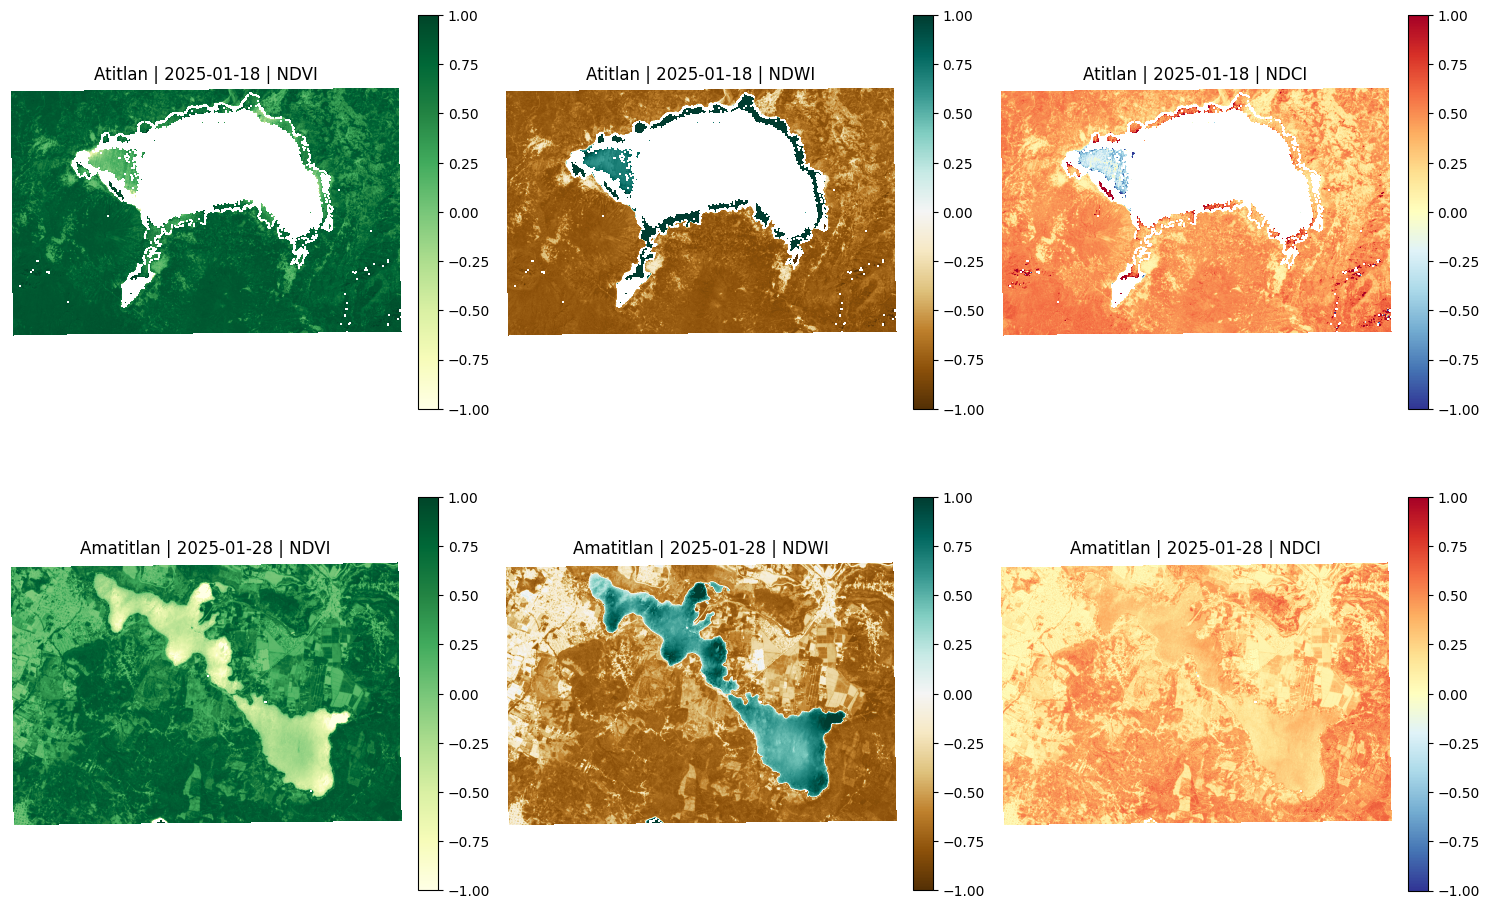

In [9]:
fig, axes = plt.subplots(len(LAKES), 3, figsize=(15, 5 * len(LAKES)), squeeze=False)
for row, lake_name in enumerate(LAKES):
    first_date = OFFICIAL_DATES[lake_name][0]
    indices = processed[(lake_name, first_date)]
    for col, (name, cmap, limits) in enumerate([
        ("ndvi", "YlGn", (-1, 1)), ("ndwi", "BrBG", (-1, 1)), ("ndci", "RdYlBu_r", (-1, 1))
    ]):
        image = np.where(indices["valid"], indices[name], np.nan)
        plot = axes[row, col].imshow(image, cmap=cmap, vmin=limits[0], vmax=limits[1])
        axes[row, col].set_title(f"{lake_name} | {first_date} | {name.upper()}")
        axes[row, col].axis("off")
        fig.colorbar(plot, ax=axes[row, col], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(DATA_DIR / "indices_muestra.png", dpi=150, bbox_inches="tight")
plt.show()

## Ejercicio 4. Análisis temporal

La métrica principal es el promedio de NDCI sobre los píxeles válidos de cada lago y fecha. La mediana, percentil 90, fracción de píxeles altos y promedios NDVI/NDWI se conservan como soporte para interpretar los resultados. El umbral de 0.20 se usa solo como indicador exploratorio de valores altos; no equivale por sí mismo a una concentración clínica o de laboratorio.

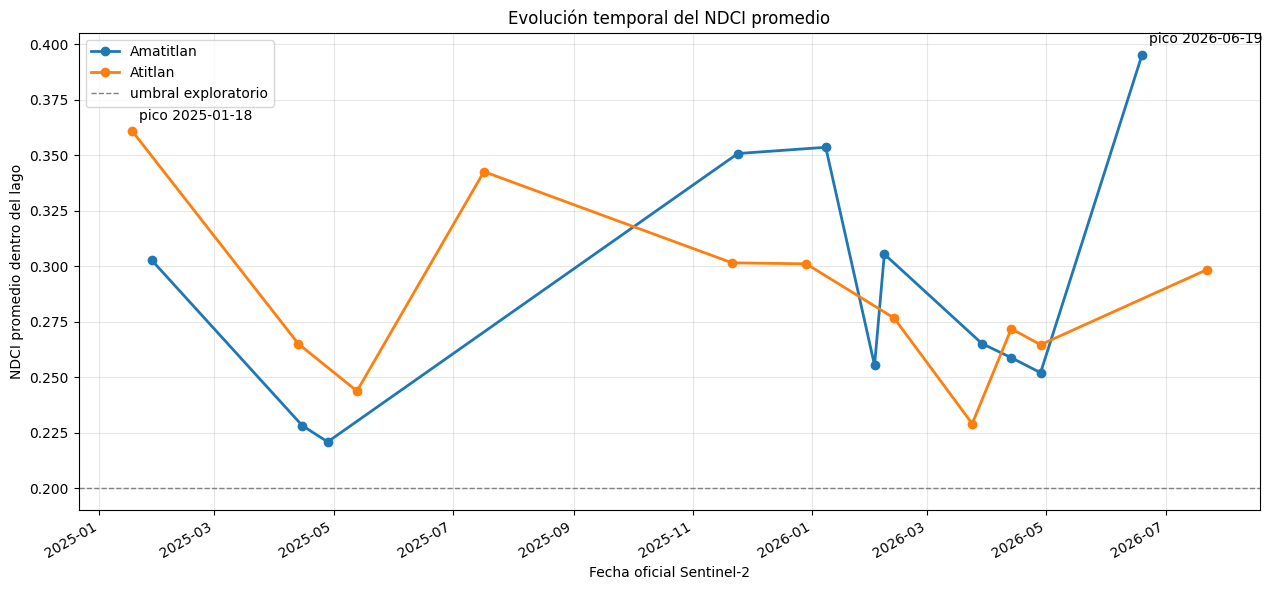

Fechas con mayor NDCI promedio por lago:


,lake,date,ndci_mean
10,Amatitlan,2026-06-19,0.395384
11,Atitlan,2025-01-18,0.360786


Resultados guardados en: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance


In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
for lake_name, group in summary.groupby("lake"):
    group = group.sort_values("date")
    ax.plot(group["date"], group["ndci_mean"], marker="o", linewidth=2, label=lake_name)
    peak = group.loc[group["ndci_mean"].idxmax()]
    ax.annotate(f"pico {peak.date:%Y-%m-%d}", (peak.date, peak.ndci_mean), xytext=(5, 8), textcoords="offset points")
ax.axhline(NDCI_HIGH_THRESHOLD, color="gray", linestyle="--", linewidth=1, label="umbral exploratorio")
ax.set_title("Evolución temporal del NDCI promedio")
ax.set_xlabel("Fecha oficial Sentinel-2")
ax.set_ylabel("NDCI promedio dentro del lago")
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(DATA_DIR / "serie_temporal_ndci.png", dpi=150, bbox_inches="tight")
plt.show()

peaks = summary.loc[summary.groupby("lake")["ndci_mean"].idxmax(), ["lake", "date", "ndci_mean"]]
print("Fechas con mayor NDCI promedio por lago:")
display(peaks)
print(f"Resultados guardados en: {DATA_DIR.resolve()}")

## Interpretación que debe acompañar al avance

La tabla y la gráfica permiten identificar fechas de mayor NDCI, pero no demuestran causalidad ambiental. En el informe se debe indicar qué lago presenta valores promedio mayores, qué fechas son críticas y si la serie aumenta, disminuye o fluctúa. También se debe reportar la cobertura válida y advertir si se utilizó el bounding box como respaldo en lugar del GeoJSON.

Los archivos producidos son `resumen_indices_por_fecha.csv`, `indices_muestra.png` y `serie_temporal_ndci.png` dentro de `data/GIS/lab4_avance`.

## Ejercicio 5. Análisis espacial

Para comparar píxeles entre fechas (mapas de diferencia, zonas persistentes) se necesita que todas las fechas de un mismo lago compartan exactamente la misma grilla espacial. Como cada descarga de openEO puede generar una rejilla ligeramente distinta, primero se reproyecta cada fecha a una grilla de referencia común (la de la primera fecha oficial de cada lago) usando `rasterio.warp.reproject`.

In [11]:
def reproject_to_reference(array, src_transform, src_crs, ref_transform, ref_crs, ref_shape,
                            resampling=WarpResampling.bilinear, fill_value=np.nan):
    destination = np.full(ref_shape, fill_value, dtype=np.float32)
    reproject(
        source=array.astype(np.float32),
        destination=destination,
        src_transform=src_transform, src_crs=src_crs,
        dst_transform=ref_transform, dst_crs=ref_crs,
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=fill_value,
    )
    return destination

ALIGNED = {}
for lake_name in LAKES:
    first_date = OFFICIAL_DATES[lake_name][0]
    reference = processed[(lake_name, first_date)]
    ref_transform, ref_crs, ref_shape = reference["transform"], reference["crs"], reference["ndci"].shape
    ALIGNED[lake_name] = {"transform": ref_transform, "crs": ref_crs, "shape": ref_shape, "dates": {}}
    for date_text in OFFICIAL_DATES[lake_name]:
        indices = processed[(lake_name, date_text)]
        ndci_r = reproject_to_reference(indices["ndci"], indices["transform"], indices["crs"],
                                         ref_transform, ref_crs, ref_shape, WarpResampling.bilinear)
        valid_f = reproject_to_reference(indices["valid"].astype(np.float32), indices["transform"], indices["crs"],
                                          ref_transform, ref_crs, ref_shape, WarpResampling.nearest, fill_value=0.0)
        ALIGNED[lake_name]["dates"][date_text] = {"ndci": ndci_r, "valid": valid_f > 0.5}

print("Grillas alineadas por lago:", {k: v["shape"] for k, v in ALIGNED.items()})

Grillas alineadas por lago: {'Atitlan': (1751, 2759), 'Amatitlan': (917, 1360)}


### 5.1 Mapa interactivo del NDCI en la fecha de mayor floración

Se reproyecta el NDCI de la fecha con mayor promedio (por lago) a EPSG:4326 y se superpone como capa semitransparente sobre un mapa base con `folium`. Los píxeles fuera del lago o cubiertos por nubes/sombras quedan completamente transparentes.

Atitlan: mapa interactivo para 2025-01-18 guardado en mapa_ndci_Atitlan_2025-01-18.html



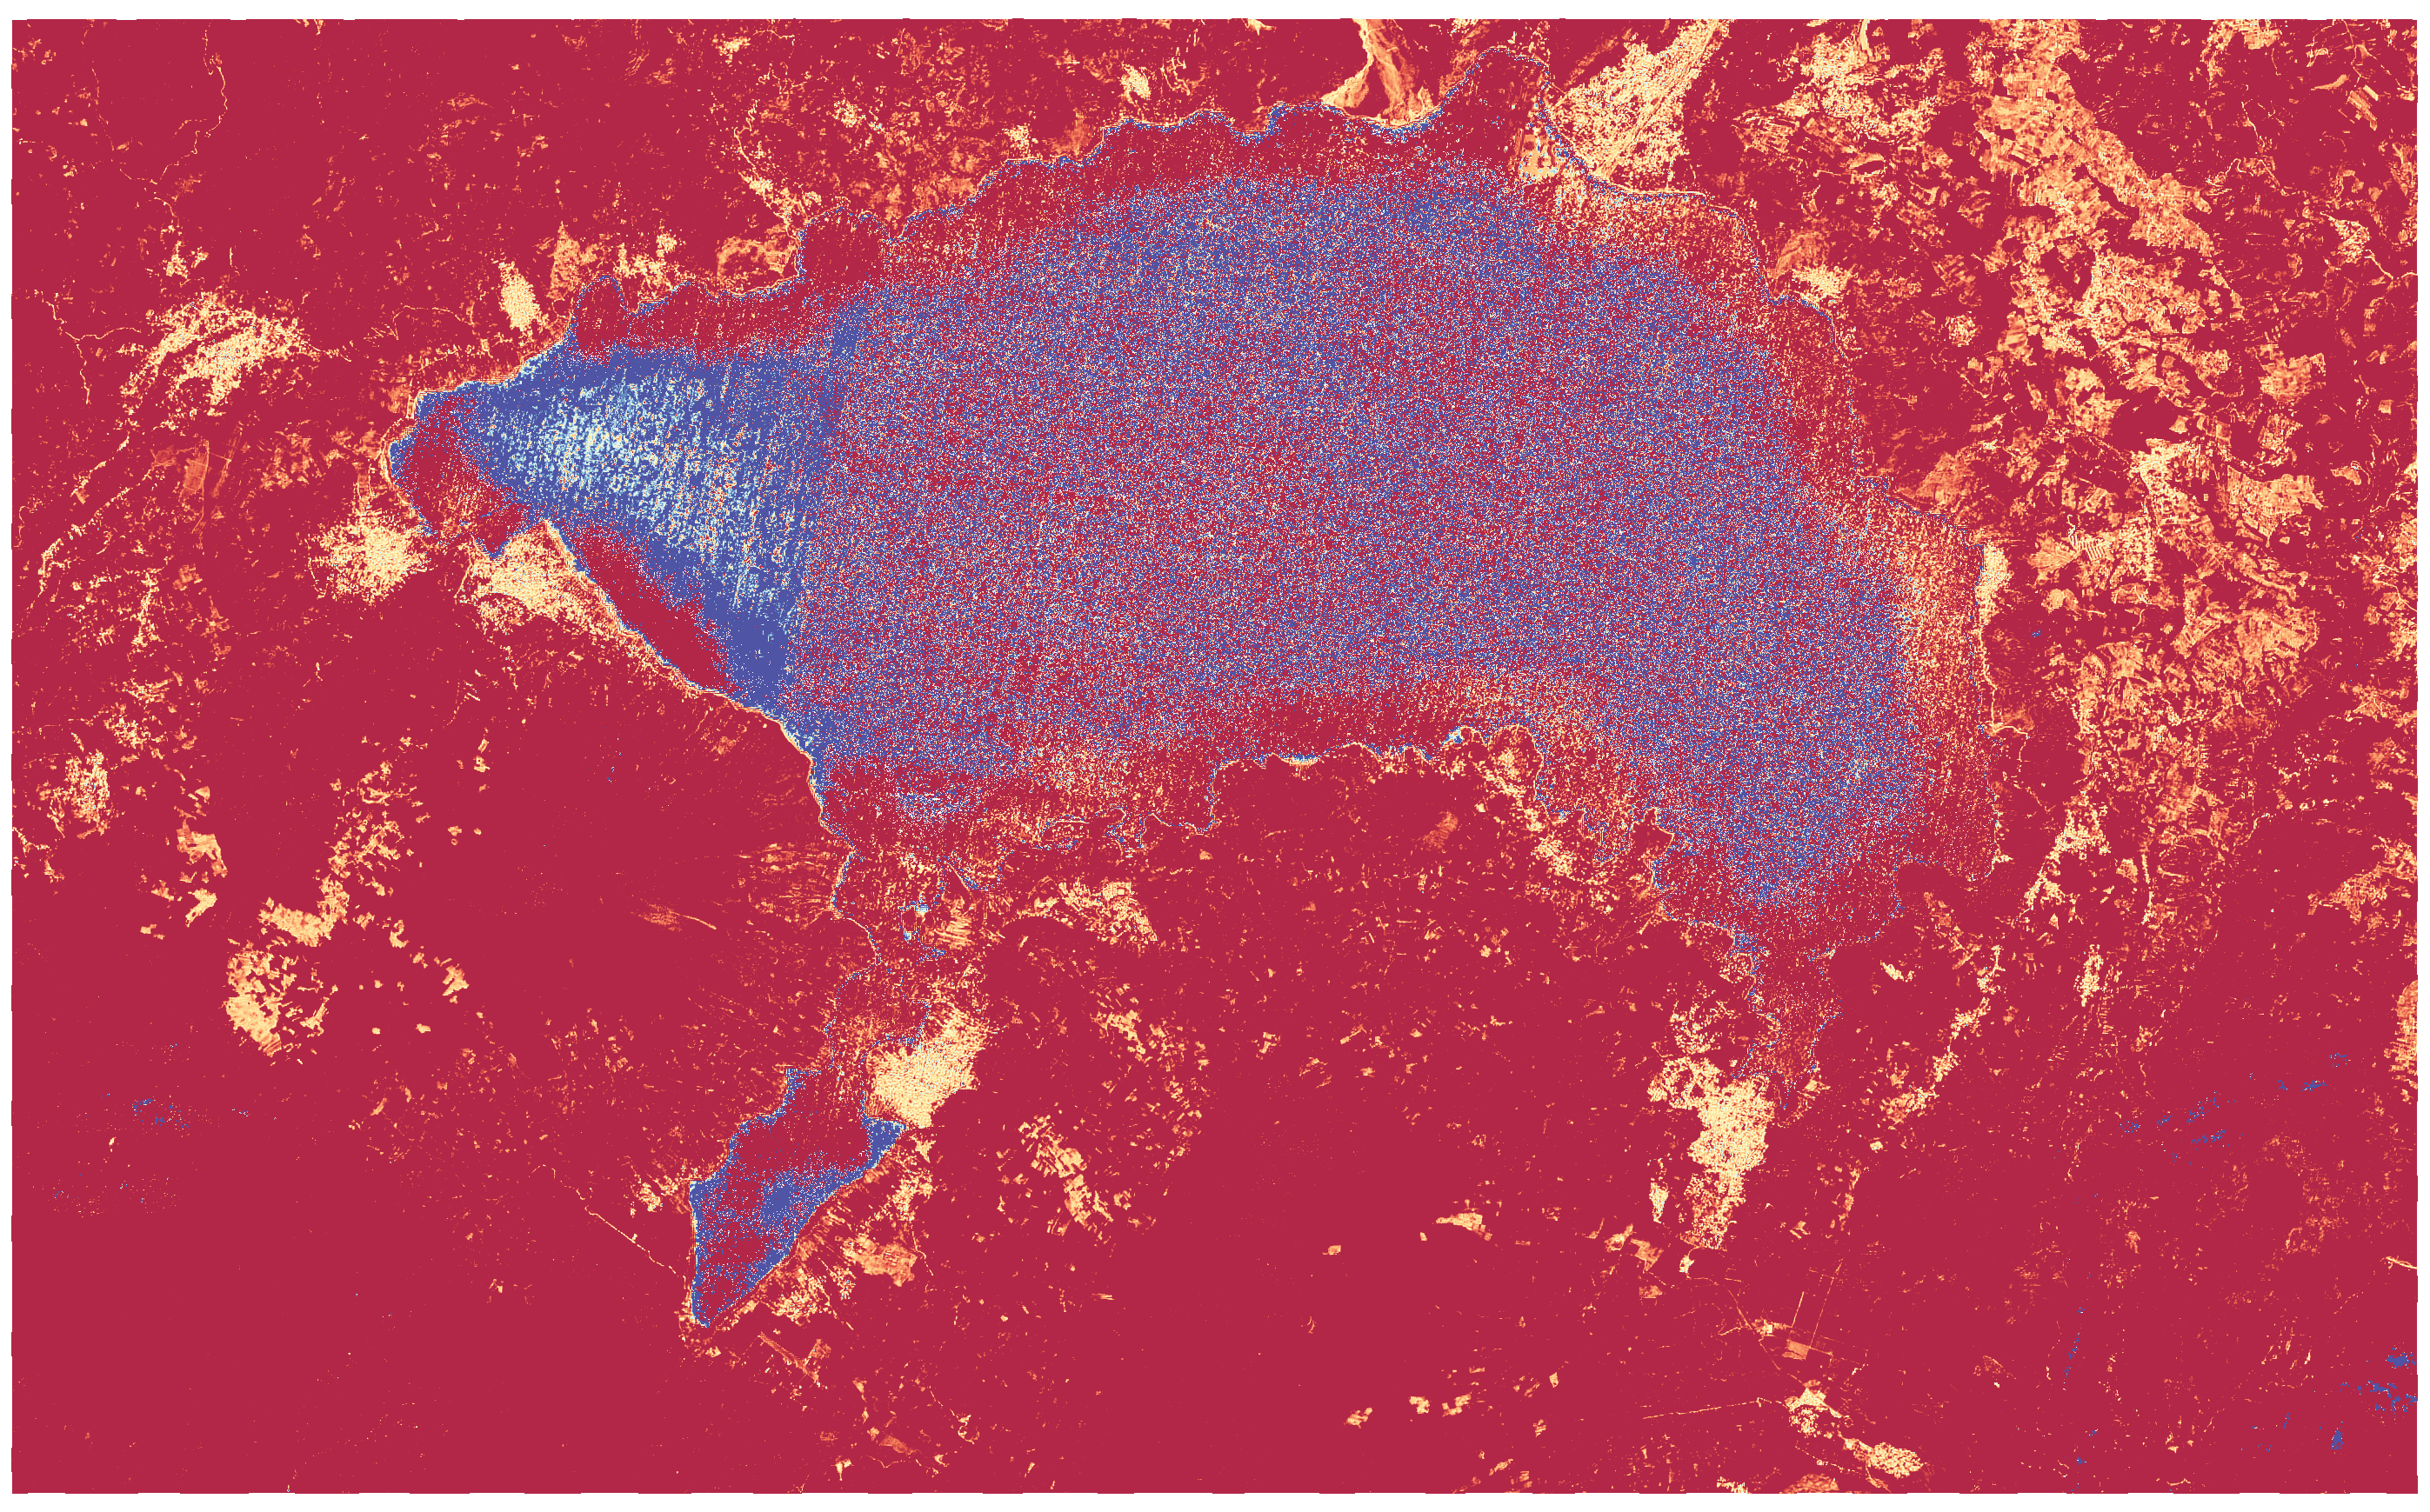

Amatitlan: mapa interactivo para 2026-06-19 guardado en mapa_ndci_Amatitlan_2026-06-19.html



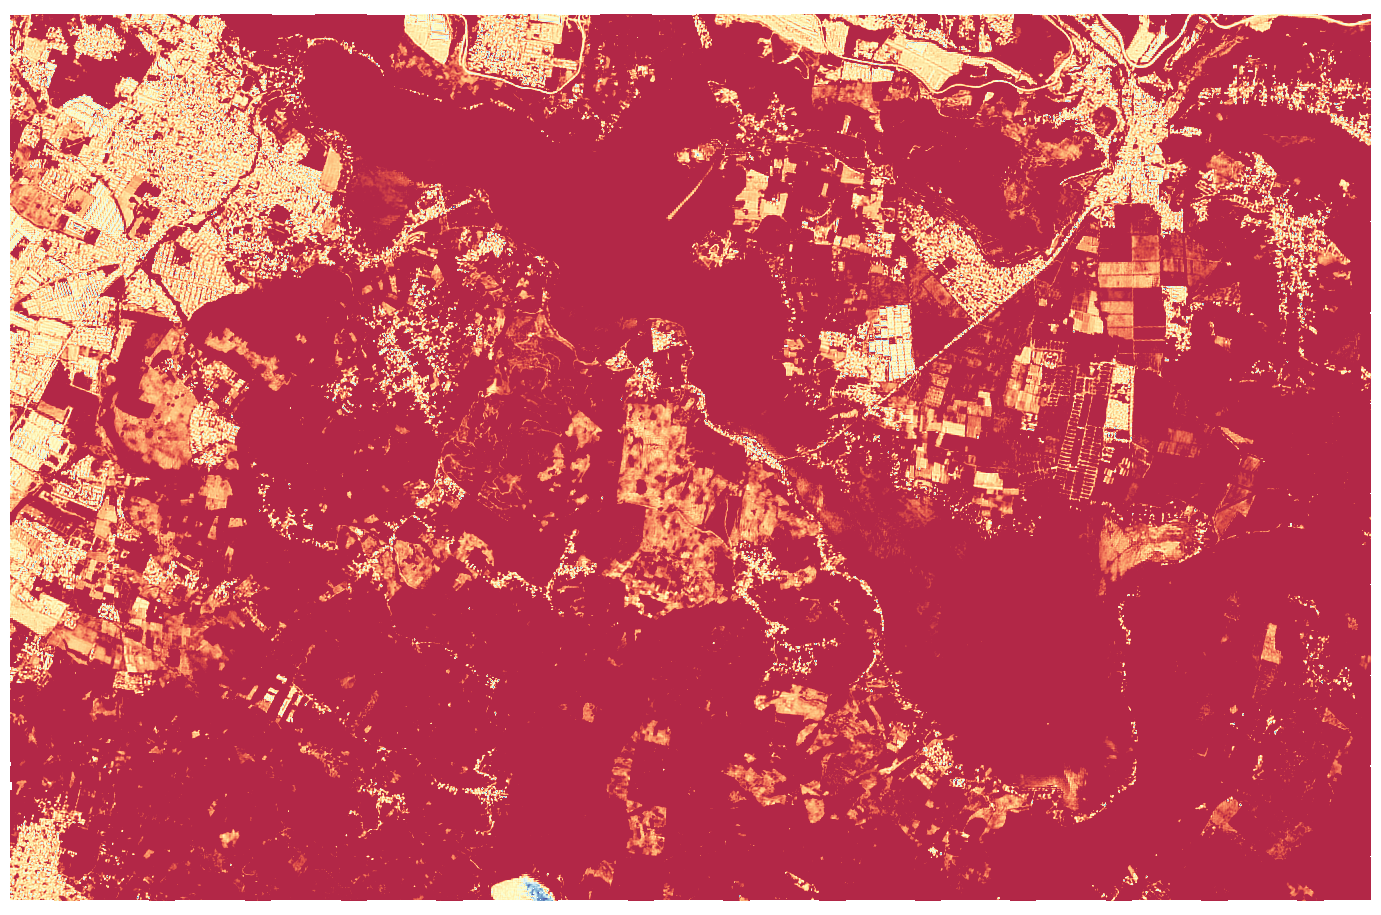

In [12]:
NDCI_VMIN, NDCI_VMAX = -0.3, 0.3
NDCI_CMAP = matplotlib.colormaps["RdYlBu_r"]

def to_latlon_rgba(ndci, valid, src_transform, src_crs, vmin=NDCI_VMIN, vmax=NDCI_VMAX):
    dst_crs = "EPSG:4326"
    west, south, east, north = array_bounds(ndci.shape[0], ndci.shape[1], src_transform)
    dst_transform, width, height = calculate_default_transform(
        src_crs, dst_crs, ndci.shape[1], ndci.shape[0], west, south, east, north,
    )
    dst_ndci = reproject_to_reference(ndci, src_transform, src_crs, dst_transform, dst_crs, (height, width),
                                       WarpResampling.bilinear)
    dst_valid = reproject_to_reference(valid.astype(np.float32), src_transform, src_crs, dst_transform, dst_crs,
                                        (height, width), WarpResampling.nearest, fill_value=0.0) > 0.5
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    rgba = NDCI_CMAP(norm(np.nan_to_num(dst_ndci, nan=vmin)))
    rgba[..., 3] = np.where(dst_valid & np.isfinite(dst_ndci), 0.85, 0.0)
    rgba_uint8 = (rgba * 255).astype(np.uint8)
    dst_west, dst_south, dst_east, dst_north = array_bounds(height, width, dst_transform)
    return rgba_uint8, [[dst_south, dst_west], [dst_north, dst_east]]

def build_ndci_folium_map(lake_name, date_text):
    indices = processed[(lake_name, date_text)]
    image, bounds = to_latlon_rgba(indices["ndci"], indices["valid"], indices["transform"], indices["crs"])
    center = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2]
    fmap = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")
    folium.raster_layers.ImageOverlay(
        image=image, bounds=bounds, opacity=1.0, name=f"NDCI {date_text}",
    ).add_to(fmap)
    colormap = LinearColormap(
        colors=[mcolors.to_hex(NDCI_CMAP(i / 255)) for i in range(0, 256, 32)],
        vmin=NDCI_VMIN, vmax=NDCI_VMAX, caption="NDCI (índice de cianobacteria)",
    )
    colormap.add_to(fmap)
    folium.LayerControl().add_to(fmap)
    return fmap

peak_dates = {}
for lake_name in LAKES:
    peak_row = summary.loc[summary["lake"] == lake_name].sort_values("ndci_mean", ascending=False).iloc[0]
    peak_dates[lake_name] = peak_row["date"].strftime("%Y-%m-%d")
    fmap = build_ndci_folium_map(lake_name, peak_dates[lake_name])
    out_path = DATA_DIR / f"mapa_ndci_{lake_name}_{peak_dates[lake_name]}.html"
    fmap.save(str(out_path))
    print(f"{lake_name}: mapa interactivo para {peak_dates[lake_name]} guardado en {out_path.name}")
    display(fmap)